# Phase 3 EDA — Kaggle Tabular Meta-Analysis

**Dataset:** `data/kaggle_meta_analysis.xlsx` — 45 entries × 36 columns  
**Scope:** PS S3–S6 + Featured/TPS competitions, 2022–2026  
**Unit of analysis:** One winning solution per competition (highest-ranked entry with a usable writeup)

Covers all Phase 3 analysis tasks from PlanV2:
1. Field completeness audit
2. Dataset overview (target type, model family, era)
3. Encoding strategy — frequency and cross-tabs
4. CV strategy by target type
5. Ensemble method — overall and by era
6. Model selection — dominant_base_model × dataset characteristics
7. FE technique frequency
8. Sparse fields and known limitations

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# Run from project root
ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

BLUE   = '#2563EB'
GREEN  = '#059669'
AMBER  = '#D97706'
PURPLE = '#7C3AED'
RED    = '#DC2626'
GRAY   = '#6B7280'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'x',
    'grid.color': '#E5E7EB',
    'grid.linewidth': 0.8,
    'figure.dpi': 130,
})

FIGDIR = 'outputs/figures'
os.makedirs(FIGDIR, exist_ok=True)

df = pd.read_excel('data/kaggle_meta_analysis.xlsx', sheet_name='Competition Data')
N = len(df)
print(f'Loaded {N} entries × {len(df.columns)} columns')
df.head(3)

Loaded 45 entries × 36 columns


,competition_ref,winner_1st,winner_2nd,winner_3rd,title,category,is_monetized,n_teams,end_date,target_type,...,ensemble_method,fe_techniques,models_used,best_single_model,hyperparameter_tuning,original_data_usage,dominant_base_model,n_rows,max_cardinality,metric
0,icr-identify-age-related-conditions,room722,Banana Overfit Capybaras,siguo,ICR - Identifying Age-Related Conditions,Featured,True,6430.0,2023-08-14,binary,...,mean_blend,No FE (overfitting); multi-label CV strategy; ...,NN,NN,not_described,not_applicable,neural_network,617,2.0,Weighted Multiclass Loss
1,playground-series-s4e7,Cross Sellers,Ujjwal Pandey,Tilii,Binary Classification of Insurance Cross Selling,Playground,False,2234.0,2024-07-31,binary,...,stacking,Feature store (12 versions); component models ...,"lightgbm, catboost, xgboost, neural_network (d...",CatBoost,manual,concat_rows,gbm,11504798,3.0,Roc Auc Score
2,playground-series-s5e3,Guillaume HIMBERT,Chris Deotte,AndNov,Binary Prediction with a Rainfall Dataset,Playground,False,4381.0,2025-03-31,binary,...,mean_blend,none,"XGBoost, CatBoost, TabPFN, LogisticRegression,...",SVC,not_described,concat_rows;merge_columns,other,2190,0.0,Roc Auc Score


In [2]:
# ── Helper: derive competition era from competition_ref ────────────────────────
def get_era(ref):
    if pd.isna(ref):
        return 'Unknown'
    r = str(ref)
    if 's6e' in r or '-s6-e' in r:
        return 'S6 (2026)'
    elif 's5e' in r or '-s5-e' in r:
        return 'S5 (2025)'
    elif 's4e' in r or '-s4-e' in r:
        return 'S4 (2024)'
    elif 's3e' in r or '-s3-e' in r:
        return 'S3 (2023)'
    else:
        return 'TPS/Featured'

df['era'] = df['competition_ref'].apply(get_era)

ERA_ORDER = ['TPS/Featured', 'S3 (2023)', 'S4 (2024)', 'S5 (2025)', 'S6 (2026)']

# ── Helper: split semicolon-separated field into individual values ─────────────
SKIP_VALS = {'not_described', 'not_applicable', 'automated', 'none', 'nan', ''}

def explode_field(series):
    """Return a flat list of all non-skip values from a semicolon-sep field."""
    out = []
    for v in series:
        if pd.isna(v):
            continue
        for part in str(v).split(';'):
            p = part.strip()
            if p and p.lower() not in SKIP_VALS:
                out.append(p)
    return out

def field_counts(series):
    return Counter(explode_field(series))

# ── Helper: n_rows bins ────────────────────────────────────────────────────────
def row_bin(n):
    if pd.isna(n):
        return 'Unknown'
    n = int(n)
    if n < 100_000:
        return 'Small (<100K)'
    elif n < 1_000_000:
        return 'Medium (100K–1M)'
    else:
        return 'Large (>1M)'

df['row_bin'] = df['n_rows'].apply(row_bin)
ROW_BIN_ORDER = ['Small (<100K)', 'Medium (100K–1M)', 'Large (>1M)']

print('Era distribution:')
print(df['era'].value_counts().reindex(ERA_ORDER))
print()
print('Row size distribution:')
print(df['row_bin'].value_counts().reindex(ROW_BIN_ORDER))

Era distribution:
era
TPS/Featured     4
S3 (2023)       17
S4 (2024)       10
S5 (2025)       10
S6 (2026)        4
Name: count, dtype: int64

Row size distribution:
row_bin
Small (<100K)       16
Medium (100K–1M)    24
Large (>1M)          5
Name: count, dtype: int64


## 1. Field Completeness Audit

In [3]:
ANALYSIS_FIELDS = [
    ('dominant_base_model',  'Model selection'),
    ('fe_techniques',        'Feature engineering'),
    ('cv_strategy',          'CV strategy'),
    ('ensemble_method',      'Ensemble method'),
    ('original_data_usage',  'Original data usage'),
    ('encoding_strategy',    'Encoding strategy'),
    ('hyperparameter_tuning','HPO strategy'),
    ('scaling',              'Scaling'),
    ('missing_data_strategy','Missing data strategy'),
    ('distribution_shift',   'Distribution shift'),
    ('n_rows',               'Training rows'),
    ('max_cardinality',      'Max cardinality'),
    ('pct_missing',          '% missing'),
]

rows_out = []
for field, label in ANALYSIS_FIELDS:
    filled = df[field].apply(
        lambda v: pd.notna(v) and str(v).strip().lower() not in SKIP_VALS
    ).sum()
    pct = filled / N * 100
    rows_out.append({'Field': label, 'Filled': f'{filled}/{N}', '%': f'{pct:.0f}%',
                     '_pct': pct})

comp_df = pd.DataFrame(rows_out).sort_values('_pct', ascending=False)
display(comp_df[['Field', 'Filled', '%']].reset_index(drop=True))

,Field,Filled,%
0,Model selection,45/45,100%
1,Training rows,45/45,100%
2,% missing,45/45,100%
3,Feature engineering,42/45,93%
4,Max cardinality,42/45,93%
5,Ensemble method,40/45,89%
6,CV strategy,39/45,87%
7,HPO strategy,30/45,67%
8,Original data usage,29/45,64%
9,Encoding strategy,27/45,60%


## 2. Dataset Overview

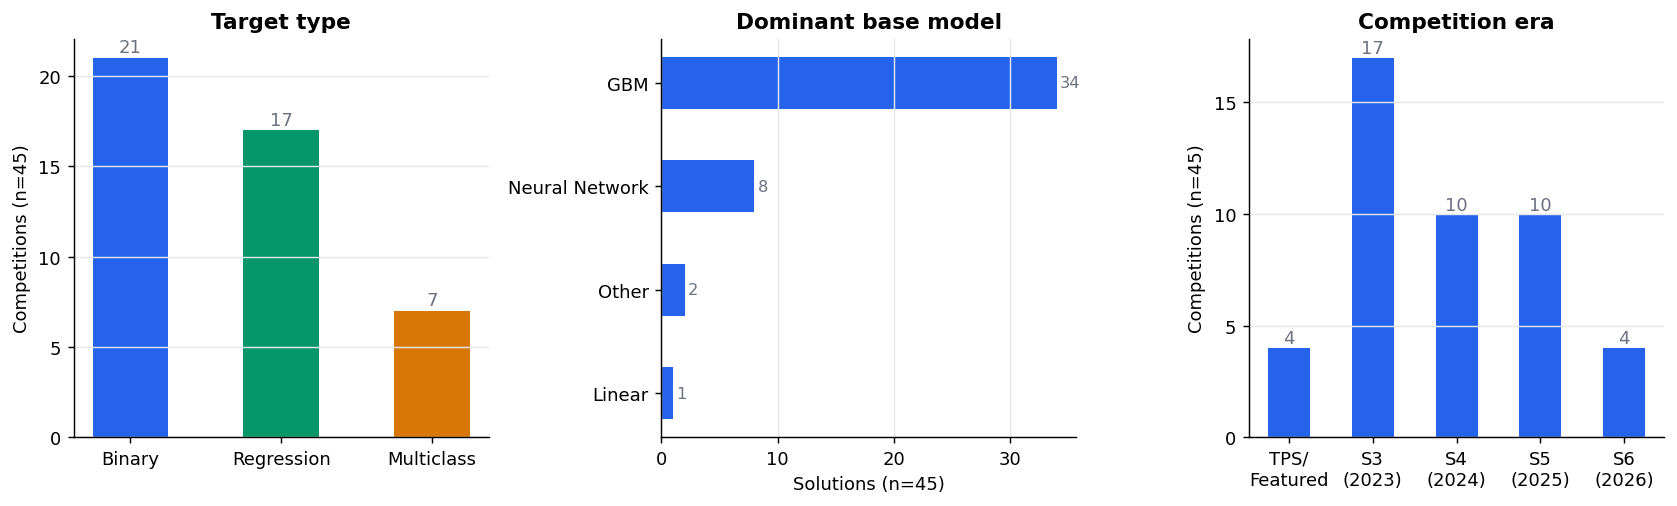

Saved eda_overview.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Target type
ax = axes[0]
tt_order = ['binary', 'regression', 'multiclass']
tt_labels = ['Binary', 'Regression', 'Multiclass']
tt_vals = [df['target_type'].value_counts().get(k, 0) for k in tt_order]
bars = ax.bar(tt_labels, tt_vals, color=[BLUE, GREEN, AMBER], width=0.5)
ax.set_title('Target type', fontweight='bold')
ax.set_ylabel(f'Competitions (n={N})')
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
for bar, v in zip(bars, tt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
            ha='center', fontsize=10, color=GRAY)

# Dominant base model
ax = axes[1]
dm_order  = ['gbm', 'neural_network', 'other', 'linear']
dm_labels = ['GBM', 'Neural Network', 'Other', 'Linear']
dm_vals = [df['dominant_base_model'].value_counts().get(k, 0) for k in dm_order]
bars = ax.barh(dm_labels[::-1], dm_vals[::-1], color=BLUE, height=0.5)
ax.set_title('Dominant base model', fontweight='bold')
ax.set_xlabel(f'Solutions (n={N})')
for bar, v in zip(bars, dm_vals[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=9, color=GRAY)

# Era breakdown
ax = axes[2]
era_vals = [df['era'].value_counts().get(k, 0) for k in ERA_ORDER]
era_labels = ['TPS/\nFeatured', 'S3\n(2023)', 'S4\n(2024)', 'S5\n(2025)', 'S6\n(2026)']
bars = ax.bar(era_labels, era_vals, color=BLUE, width=0.5)
ax.set_title('Competition era', fontweight='bold')
ax.set_ylabel(f'Competitions (n={N})')
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
for bar, v in zip(bars, era_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(v),
            ha='center', fontsize=10, color=GRAY)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_overview.png')

## 3. Model Family Usage

Counts how many winning solutions used each model family (multi-select from `models_used`).

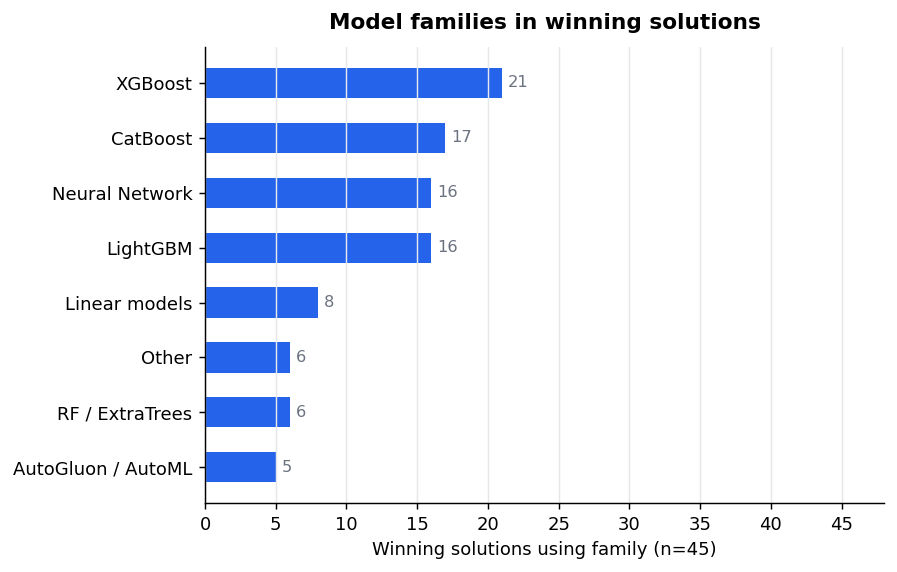

Saved eda_model_families.png


In [5]:
MODEL_FAMILIES = {
    'LightGBM':           ['LightGBM'],
    'XGBoost':            ['XGBoost'],
    'CatBoost':           ['CatBoost'],
    'Neural Network':     ['NN', 'TabPFN', 'TabNet', 'TabM', 'RealMLP', 'FastAI',
                           'MLP', 'Autoencoder', 'SAINT', 'DCN', 'NAM', 'SNN',
                           'IFAN', 'RFF'],
    'AutoGluon / AutoML': ['AutoGluon', 'AutoML', 'LightAutoML', 'H2O', 'FLAML'],
    'RF / ExtraTrees':    ['RandomForest', 'ExtraTrees', 'HistGB', 'GradientBoosting'],
    'Linear models':      ['LinearRegression', 'Lasso', 'Ridge', 'LogisticRegression'],
    'Other':              ['SVR', 'SVC', 'KNN', 'GAM', 'Cox', 'RadiusNeighbors'],
}

model_counts = Counter()
for val in df['models_used']:
    if pd.isna(val) or str(val).lower() in SKIP_VALS:
        continue
    for family, aliases in MODEL_FAMILIES.items():
        if any(alias in str(val) for alias in aliases):
            model_counts[family] += 1

families = [f for f, _ in model_counts.most_common()]
counts   = [model_counts[f] for f in families]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(families[::-1], counts[::-1], color=BLUE, height=0.55)
ax.set_xlabel(f'Winning solutions using family (n={N})')
ax.set_title('Model families in winning solutions', fontweight='bold', pad=10)
ax.set_xlim(0, N + 3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9, color=GRAY)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_model_families.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_model_families.png')

## 4. Ensemble Methods

Overall distribution and breakdown by competition era.

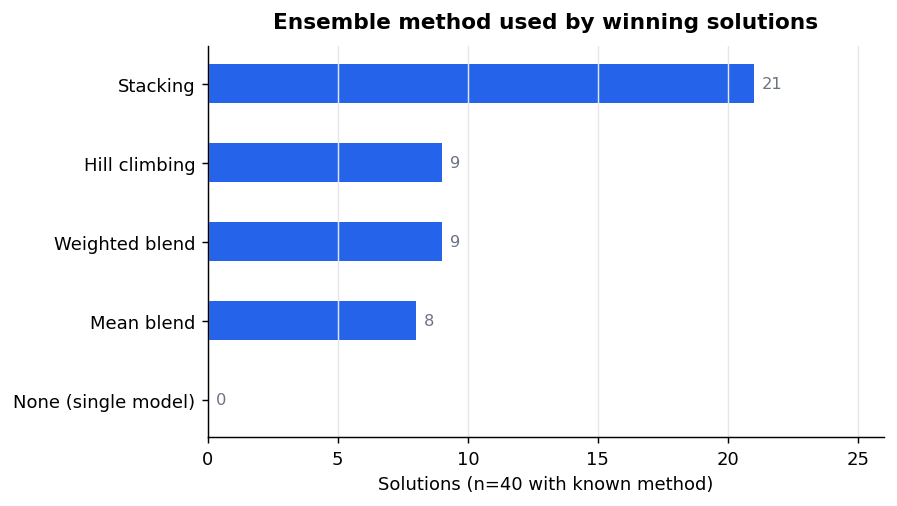

Saved eda_ensemble_overall.png

Note: entries may list multiple methods (;-separated). Total tag count = 47


In [6]:
# Overall ensemble method distribution
em_counts = field_counts(df['ensemble_method'])
n_em = df['ensemble_method'].apply(
    lambda v: pd.notna(v) and str(v).lower() not in SKIP_VALS
).sum()

EM_ORDER  = ['stacking', 'hill_climbing', 'weighted_blend', 'mean_blend', 'none']
EM_LABELS = ['Stacking', 'Hill climbing', 'Weighted blend', 'Mean blend', 'None (single model)']
em_vals   = [em_counts.get(k, 0) for k in EM_ORDER]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(EM_LABELS[::-1], em_vals[::-1], color=BLUE, height=0.5)
ax.set_xlabel(f'Solutions (n={n_em} with known method)')
ax.set_title('Ensemble method used by winning solutions', fontweight='bold', pad=10)
ax.set_xlim(0, max(em_vals) + 5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
for bar, v in zip(bars, em_vals[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=9, color=GRAY)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_ensemble_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_ensemble_overall.png')
print(f'\nNote: entries may list multiple methods (;-separated). Total tag count = {sum(em_vals)}')

Ensemble method counts by era (entries may have multiple methods):
              stacking  hill_climbing  weighted_blend  mean_blend  none
TPS/Featured         0              0               0           3     0
S3 (2023)            9              2               3           4     0
S4 (2024)            4              2               5           0     0
S5 (2025)            4              5               1           1     0
S6 (2026)            4              0               0           0     0



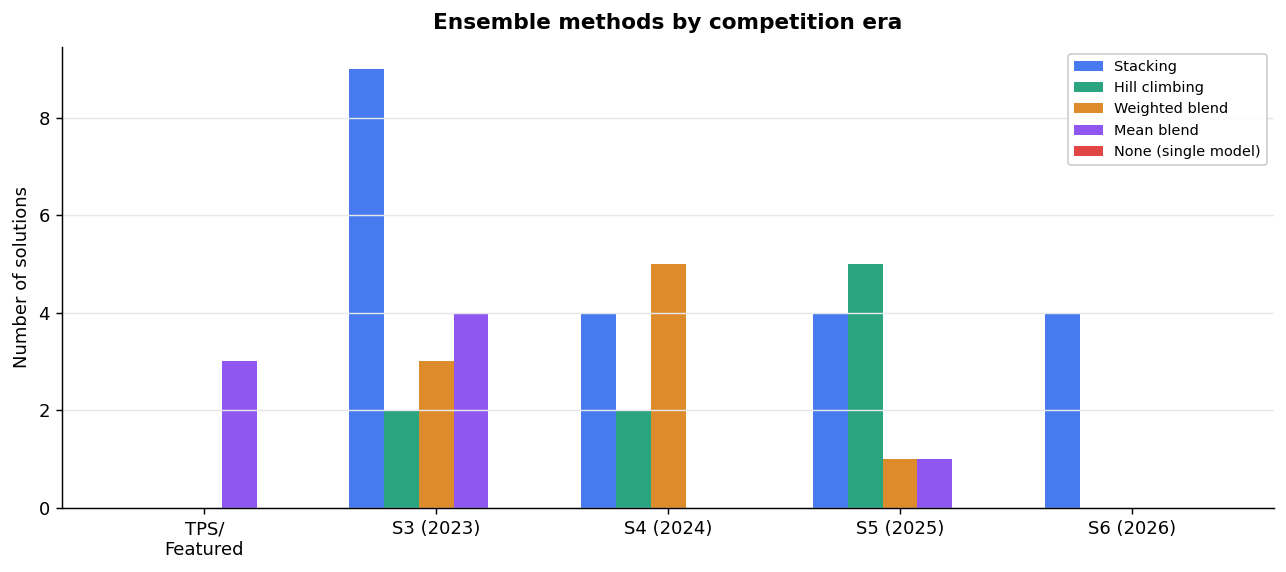

Saved eda_ensemble_by_era.png


In [7]:
# Ensemble method by era — stacked bar showing which methods dominate in each era
# Each era: count entries that include each method

era_em = {}
for era in ERA_ORDER:
    sub = df[df['era'] == era]['ensemble_method']
    era_em[era] = field_counts(sub)

# Build matrix: rows=ERA_ORDER, cols=EM_ORDER
em_matrix = pd.DataFrame(
    {em: [era_em[era].get(em, 0) for era in ERA_ORDER] for em in EM_ORDER},
    index=ERA_ORDER
)

print('Ensemble method counts by era (entries may have multiple methods):')
print(em_matrix.to_string())
print()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 4.5))
bar_colors = [BLUE, GREEN, AMBER, PURPLE, RED]
x = np.arange(len(ERA_ORDER))
width = 0.15
for i, (em, label, color) in enumerate(zip(EM_ORDER, EM_LABELS, bar_colors)):
    offset = (i - len(EM_ORDER)/2 + 0.5) * width
    vals = em_matrix[em].values
    ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([e.replace('/', '/\n') for e in ERA_ORDER])
ax.set_ylabel('Number of solutions')
ax.set_title('Ensemble methods by competition era', fontweight='bold', pad=10)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_ensemble_by_era.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_ensemble_by_era.png')

## 5. Encoding Strategy

Overall frequency, then cross-tabulated by `feature_type_dominant` and `target_type`.

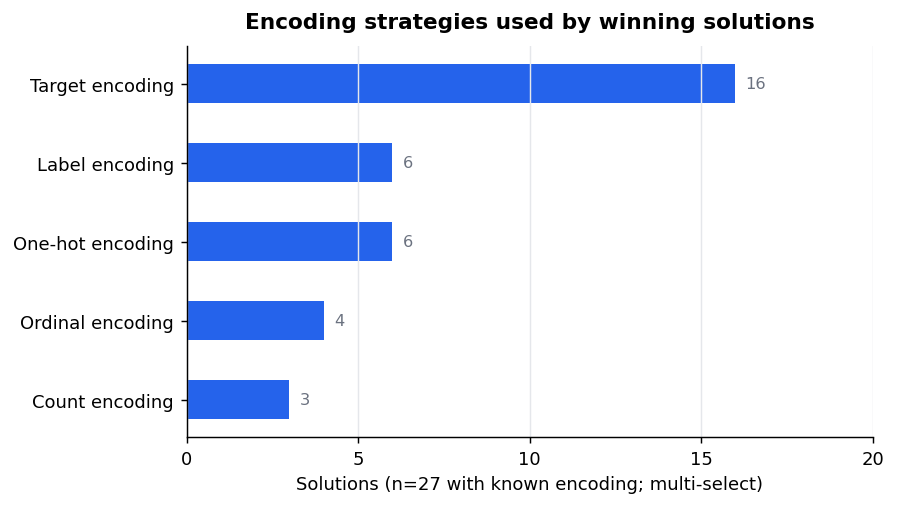

Saved eda_encoding_overall.png


In [8]:
enc_counts = field_counts(df['encoding_strategy'])
n_enc = df['encoding_strategy'].apply(
    lambda v: pd.notna(v) and str(v).lower() not in SKIP_VALS
).sum()

ENC_ORDER  = ['target_encoding', 'label_encoding', 'one_hot_encoding',
              'ordinal_encoding', 'count_encoding']
ENC_LABELS = ['Target encoding', 'Label encoding', 'One-hot encoding',
              'Ordinal encoding', 'Count encoding']

# Add any values not in our order list
extra = [k for k in enc_counts if k not in ENC_ORDER]
ENC_ORDER.extend(extra); ENC_LABELS.extend(extra)

enc_vals = [enc_counts.get(k, 0) for k in ENC_ORDER]
# Filter zeros
pairs = [(l, v) for l, v in zip(ENC_LABELS, enc_vals) if v > 0]
ENC_LABELS_PLOT, enc_vals_plot = zip(*pairs)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(list(ENC_LABELS_PLOT)[::-1], list(enc_vals_plot)[::-1], color=BLUE, height=0.5)
ax.set_xlabel(f'Solutions (n={n_enc} with known encoding; multi-select)')
ax.set_title('Encoding strategies used by winning solutions', fontweight='bold', pad=10)
ax.set_xlim(0, max(enc_vals_plot) + 4)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
for bar, v in zip(bars, list(enc_vals_plot)[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=9, color=GRAY)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_encoding_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_encoding_overall.png')

In [9]:
# Cross-tab: encoding strategy × feature_type_dominant
# For entries with known encoding, explode into one row per encoding method
records = []
for _, row in df.iterrows():
    enc = str(row['encoding_strategy']) if pd.notna(row['encoding_strategy']) else ''
    if not enc or enc.lower() in SKIP_VALS:
        continue
    for method in enc.split(';'):
        m = method.strip()
        if m and m.lower() not in SKIP_VALS:
            records.append({
                'encoding': m,
                'feature_type': row['feature_type_dominant'],
                'target_type':  row['target_type'],
                'era':          row['era'],
            })

enc_df = pd.DataFrame(records)

print('=== Encoding strategy × Feature type dominant ===')
ct1 = pd.crosstab(enc_df['encoding'], enc_df['feature_type'])
ct1['TOTAL'] = ct1.sum(axis=1)
display(ct1.sort_values('TOTAL', ascending=False))

print()
print('=== Encoding strategy × Target type ===')
ct2 = pd.crosstab(enc_df['encoding'], enc_df['target_type'])
ct2['TOTAL'] = ct2.sum(axis=1)
display(ct2.sort_values('TOTAL', ascending=False))

=== Encoding strategy × Feature type dominant ===


feature_type,mixed,numeric,TOTAL
encoding,,,
target_encoding,15,1,16
one_hot_encoding,6,0,6
label_encoding,6,0,6
ordinal_encoding,4,0,4
count_encoding,3,0,3



=== Encoding strategy × Target type ===


target_type,binary,multiclass,regression,TOTAL
encoding,,,,
target_encoding,7,2,7,16
one_hot_encoding,2,0,4,6
label_encoding,2,0,4,6
ordinal_encoding,3,0,1,4
count_encoding,2,0,1,3


In [10]:
# Encoding strategy × max_cardinality
# max_cardinality=0 means all-numeric (no categoricals). Bin entries with categoricals.

def cardinality_bin(c):
    if pd.isna(c):
        return 'Unknown'
    c = int(float(c))
    if c == 0:
        return 'None (all numeric)'
    elif c <= 10:
        return 'Low (1–10)'
    elif c <= 100:
        return 'Medium (11–100)'
    else:
        return 'High (>100)'

df['card_bin'] = df['max_cardinality'].apply(cardinality_bin)
CARD_ORDER = ['None (all numeric)', 'Low (1–10)', 'Medium (11–100)', 'High (>100)', 'Unknown']

records2 = []
for _, row in df.iterrows():
    enc = str(row['encoding_strategy']) if pd.notna(row['encoding_strategy']) else ''
    if not enc or enc.lower() in SKIP_VALS:
        continue
    for method in enc.split(';'):
        m = method.strip()
        if m and m.lower() not in SKIP_VALS:
            records2.append({'encoding': m, 'card_bin': row['card_bin']})

enc_card_df = pd.DataFrame(records2)

print('=== Encoding strategy × Cardinality bin ===')
ct3 = pd.crosstab(enc_card_df['encoding'], enc_card_df['card_bin'])
for col in CARD_ORDER:
    if col not in ct3.columns:
        ct3[col] = 0
ct3 = ct3[CARD_ORDER]
ct3['TOTAL'] = ct3.sum(axis=1)
display(ct3.sort_values('TOTAL', ascending=False))

print('\nNote: max_cardinality is null for', df['max_cardinality'].isna().sum(),
      'entries (likely 403 on data download). These appear under Unknown.')

=== Encoding strategy × Cardinality bin ===


card_bin,None (all numeric),Low (1–10),Medium (11–100),High (>100),Unknown,TOTAL
encoding,,,,,,
target_encoding,0,8,5,3,0,16
one_hot_encoding,0,2,1,1,2,6
label_encoding,0,4,0,2,0,6
ordinal_encoding,0,2,0,2,0,4
count_encoding,0,0,2,1,0,3



Note: max_cardinality is null for 3 entries (likely 403 on data download). These appear under Unknown.


## 6. CV Strategy by Target Type

Overall CV strategy (n=39 entries with known strategy):
stratified_kfold             18
kfold                        11
repeated_kfold                5
repeated_stratified_kfold     3
grouped                       1
post_cutoff                   1

=== CV strategy × Target type ===


target_type,binary,multiclass,regression,TOTAL
cv,,,,
stratified_kfold,14,3,1,18
kfold,2,0,9,11
repeated_kfold,1,0,4,5
repeated_stratified_kfold,1,1,1,3
grouped,1,0,0,1
post_cutoff,1,0,0,1


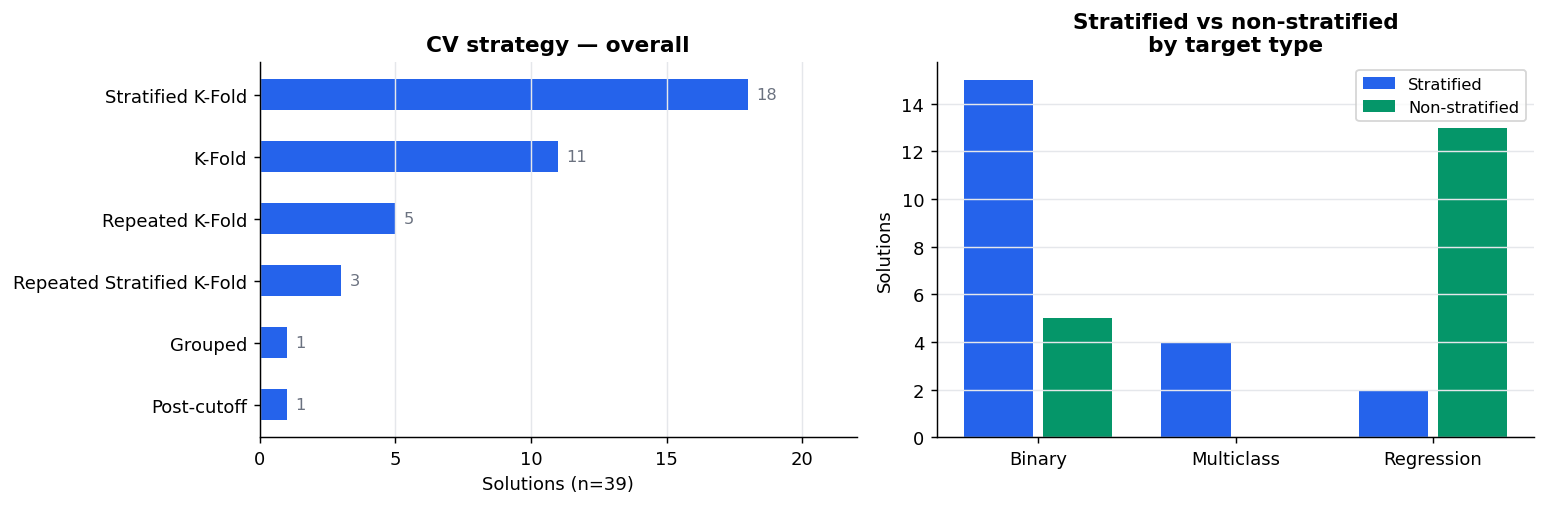

Saved eda_cv_strategy.png


In [11]:
cv_counts = field_counts(df['cv_strategy'])
n_cv = df['cv_strategy'].apply(
    lambda v: pd.notna(v) and str(v).lower() not in SKIP_VALS
).sum()

CV_ORDER  = ['stratified_kfold', 'kfold', 'repeated_kfold',
             'repeated_stratified_kfold', 'grouped', 'post_cutoff']
CV_LABELS = ['Stratified K-Fold', 'K-Fold', 'Repeated K-Fold',
             'Repeated Stratified K-Fold', 'Grouped', 'Post-cutoff']

# Cross-tab: CV × target_type
cv_records = []
for _, row in df.iterrows():
    cv = str(row['cv_strategy']) if pd.notna(row['cv_strategy']) else ''
    if not cv or cv.lower() in SKIP_VALS:
        continue
    for method in cv.split(';'):
        m = method.strip()
        if m and m.lower() not in SKIP_VALS:
            cv_records.append({'cv': m, 'target_type': row['target_type']})

cv_df = pd.DataFrame(cv_records)

print(f'Overall CV strategy (n={n_cv} entries with known strategy):')
print(pd.Series(cv_counts).sort_values(ascending=False).to_string())
print()

print('=== CV strategy × Target type ===')
ct_cv = pd.crosstab(cv_df['cv'], cv_df['target_type'])
ct_cv['TOTAL'] = ct_cv.sum(axis=1)
display(ct_cv.sort_values('TOTAL', ascending=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall CV frequency
ax = axes[0]
cv_vals = [cv_counts.get(k, 0) for k in CV_ORDER]
pairs = [(l, v) for l, v in zip(CV_LABELS, cv_vals) if v > 0]
cv_labs, cv_vs = zip(*pairs)
bars = ax.barh(list(cv_labs)[::-1], list(cv_vs)[::-1], color=BLUE, height=0.5)
ax.set_xlabel(f'Solutions (n={n_cv})')
ax.set_title('CV strategy — overall', fontweight='bold')
ax.set_xlim(0, max(cv_vs) + 4)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
for bar, v in zip(bars, list(cv_vs)[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=9, color=GRAY)

# Right: stratified vs non-stratified by target_type
ax = axes[1]
tt_order = ['binary', 'multiclass', 'regression']
stratified_keys = {'stratified_kfold', 'repeated_stratified_kfold'}
strat_counts, nonstrat_counts = [], []
for tt in tt_order:
    sub = df[df['target_type'] == tt]['cv_strategy']
    c = field_counts(sub)
    strat_counts.append(sum(c.get(k, 0) for k in stratified_keys))
    nonstrat_counts.append(sum(c.get(k, 0) for k in c if k not in stratified_keys))

x = np.arange(len(tt_order))
ax.bar(x - 0.2, strat_counts, 0.35, label='Stratified', color=BLUE)
ax.bar(x + 0.2, nonstrat_counts, 0.35, label='Non-stratified', color=GREEN)
ax.set_xticks(x)
ax.set_xticklabels(['Binary', 'Multiclass', 'Regression'])
ax.set_ylabel('Solutions')
ax.set_title('Stratified vs non-stratified\nby target type', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_cv_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_cv_strategy.png')

## 7. Model Selection — GBM vs. Neural Network vs. Dataset Characteristics

In [12]:
# dominant_base_model × row_bin and × has_categorical

print('=== dominant_base_model × Training set size ===')
ct_rows = pd.crosstab(df['dominant_base_model'], df['row_bin'])
for col in ROW_BIN_ORDER:
    if col not in ct_rows.columns:
        ct_rows[col] = 0
ct_rows = ct_rows[ROW_BIN_ORDER]
ct_rows['TOTAL'] = ct_rows.sum(axis=1)
display(ct_rows)

print()
print('=== dominant_base_model × Has categorical features ===')
ct_cat = pd.crosstab(df['dominant_base_model'], df['has_categorical'])
ct_cat['TOTAL'] = ct_cat.sum(axis=1)
display(ct_cat)

# GBM vs NN summary with pct_missing and n_rows (descriptive stats)
print()
print('=== Dataset characteristics by dominant model ===')
summary = df[df['dominant_base_model'].isin(['gbm', 'neural_network'])].groupby('dominant_base_model').agg(
    n=('competition_ref', 'count'),
    median_rows=('n_rows', 'median'),
    mean_rows=('n_rows', 'mean'),
    median_pct_missing=('pct_missing', 'median'),
    pct_has_categorical=('has_categorical', lambda x: x.apply(bool).mean() * 100),
).round(1)
display(summary)

=== dominant_base_model × Training set size ===


row_bin,Small (<100K),Medium (100K–1M),Large (>1M),TOTAL
dominant_base_model,,,,
gbm,14,16,4,34
linear,0,1,0,1
neural_network,1,6,1,8
other,1,1,0,2



=== dominant_base_model × Has categorical features ===


has_categorical,False,True,TOTAL
dominant_base_model,,,
gbm,11,23,34
linear,1,0,1
neural_network,1,7,8
other,2,0,2



=== Dataset characteristics by dominant model ===


,n,median_rows,mean_rows,median_pct_missing,pct_has_categorical
dominant_base_model,,,,,
gbm,34,149978.0,700109.7,0.0,67.6
neural_network,8,630000.0,586668.0,0.0,87.5


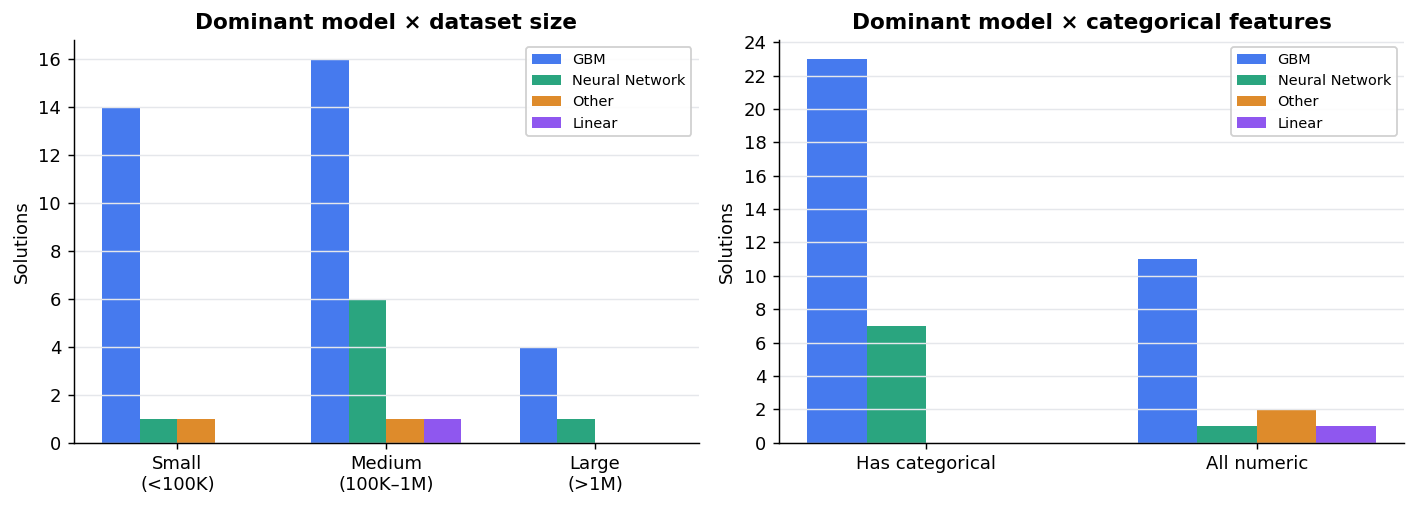

Saved eda_model_selection.png


In [13]:
# Visualise model selection patterns
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: model × row_bin
ax = axes[0]
models_to_show = ['gbm', 'neural_network', 'other', 'linear']
model_labels   = ['GBM', 'Neural Network', 'Other', 'Linear']
bar_cols = [BLUE, GREEN, AMBER, PURPLE]
x = np.arange(len(ROW_BIN_ORDER))
width = 0.18
for i, (m, ml, c) in enumerate(zip(models_to_show, model_labels, bar_cols)):
    vals = [ct_rows.loc[m, rb] if m in ct_rows.index and rb in ct_rows.columns else 0
            for rb in ROW_BIN_ORDER]
    offset = (i - len(models_to_show)/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=ml, color=c, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Small\n(<100K)', 'Medium\n(100K–1M)', 'Large\n(>1M)'])
ax.set_ylabel('Solutions')
ax.set_title('Dominant model × dataset size', fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

# Right: model × has_categorical (Excel booleans read as Python bool True/False)
ax = axes[1]
for i, (m, ml, c) in enumerate(zip(models_to_show, model_labels, bar_cols)):
    row = ct_cat.loc[m] if m in ct_cat.index else pd.Series({True: 0, False: 0})
    vals = [row.get(True, 0), row.get(False, 0)]
    offset = (i - len(models_to_show)/2 + 0.5) * width
    ax.bar(np.arange(2) + offset, vals, width, label=ml, color=c, alpha=0.85)
ax.set_xticks(np.arange(2))
ax.set_xticklabels(['Has categorical', 'All numeric'])
ax.set_ylabel('Solutions')
ax.set_title('Dominant model × categorical features', fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig(f'{FIGDIR}/eda_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved eda_model_selection.png')

## 9. Sparse Fields & Known Limitations

In [14]:
print('=== Scaling (12/45 = 27% with explicit values) ===')
sc = field_counts(df['scaling'])
print(dict(sc.most_common()))
print('Root cause: GBM authors do not mention scaling because trees are scale-invariant.')
print('Missing values are likely "none" not "unknown". Excluded from flowchart nodes.')
print()

print('=== Missing data strategy (8/45 = 18% with explicit values) ===')
ms = field_counts(df['missing_data_strategy'])
print(dict(ms.most_common()))
print('Same root cause as scaling. Excluded from flowchart nodes.')
print()

print('=== Distribution shift (only TRUE/FALSE values, not not_described) ===')
ds_counts = df['distribution_shift'].value_counts()
print(ds_counts.to_dict())
filled_ds = ds_counts.get('TRUE', 0) + ds_counts.get('FALSE', 0)
print(f'Meaningful values: {filled_ds}/45 ({filled_ds/45*100:.0f}%)')
print('Too sparse to use as CV strategy decision node input. Dropped from flowchart.')
print()

print('=== max_cardinality — null entries ===')
null_card = df['max_cardinality'].isna().sum()
print(f'Null: {null_card}/45. Cause: HTTP 403 on data download for some competitions.')
print()

print('=== Monetized competitions ===')
# is_monetized is stored as Excel boolean — read as Python bool, not string 'TRUE'
mon = df['is_monetized'].apply(bool).sum()
print(f'Monetized: {mon}/45. Planned monetized vs. playground comparison is not viable at n=1.')
print()

print('=== S6 KGMON entries (methodologically distinct) ===')
s6_n = (df['era'] == 'S6 (2026)').sum()
print(f'S6 entries: {s6_n}/45. Mega-stacks with 100+ models. Track era as covariate in analysis.')

=== Scaling (12/45 = 27% with explicit values) ===
{'standard': 9, 'log': 2}
Root cause: GBM authors do not mention scaling because trees are scale-invariant.
Missing values are likely "none" not "unknown". Excluded from flowchart nodes.

=== Missing data strategy (8/45 = 18% with explicit values) ===
{'imputation': 5, 'fill_missing_category': 1}
Same root cause as scaling. Excluded from flowchart nodes.

=== Distribution shift (only TRUE/FALSE values, not not_described) ===
{'not_described': 32, 'FALSE': 8, 'TRUE': 5}
Meaningful values: 13/45 (29%)
Too sparse to use as CV strategy decision node input. Dropped from flowchart.

=== max_cardinality — null entries ===
Null: 3/45. Cause: HTTP 403 on data download for some competitions.

=== Monetized competitions ===
Monetized: 1/45. Planned monetized vs. playground comparison is not viable at n=1.

=== S6 KGMON entries (methodologically distinct) ===
S6 entries: 4/45. Mega-stacks with 100+ models. Track era as covariate in analysis.


## 10. Summary of Key Findings

### Model selection
- GBM (XGBoost, LightGBM, CatBoost) dominates: **34/45 (75%)** winning solutions.
- Neural network wins: **8/45 (18%)**. NN findings are descriptive only — sample too small for inference.
- GBM wins occur across all dataset sizes and both feature types (mixed and all-numeric).

### Ensemble methods
- Stacking is the most common ensemble strategy, followed by hill climbing and weighted/mean blending.
- Single-model wins are rare across S3–S5. S6 entries (KGMON) represent an extreme — 100+ model mega-stacks.

### Encoding strategy
- Target encoding is the dominant approach (18 of 29 entries with known encoding), particularly for mixed-feature datasets with moderate-to-high cardinality.
- One-hot and label encoding appear mainly in low-cardinality datasets.

### CV strategy
- Stratified K-Fold is the default: **19/39** entries with known CV use it.
- Plain K-Fold is used in 10 entries, almost exclusively for regression targets.
- Repeated variants appear in 8 entries, concentrated in small-dataset competitions where variance reduction matters.

### Feature engineering
- FE choices varied widely across competitions and were highly dataset-specific, consistent with the view that feature engineering requires domain knowledge that resists generalization. The encoding strategy cross-tabs above capture the structured FE signal that feeds the flowchart.

### Sparse fields
- `scaling` (27%) and `missing_data_strategy` (18%): excluded from flowchart nodes. Sparse because GBM authors don't mention them — likely `none` in most cases.
- `distribution_shift` (29% with TRUE/FALSE values): dropped as a CV decision node input.
- `max_cardinality`: null for some entries due to HTTP 403 on data download; treat as missing at random.